In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [32]:

# ============================================================
# 1. LOAD ẢNH MÀU RGB TỪ FILE LOCAL
# ============================================================
# HƯỚNG DẪN: Thay 'image.jpg' bằng đường dẫn ảnh của bạn
# Ví dụ:
#   - Windows: 'C:/Users/YourName/Pictures/photo.jpg'
#   - Linux/Mac: '/home/username/images/photo.jpg'
#   - Đường dẫn tương đối: 'data/sample.jpg'

IMAGE_PATH = 'sample\gcl.jpg'  # <--- THAY ĐỔI ĐƯỜNG DẪN TẠI ĐÂY

# Load ảnh bằng OpenCV (mặc định là BGR)
img_bgr = cv2.imread(IMAGE_PATH)

# Kiểm tra xem ảnh có load thành công không
if img_bgr is None:
    raise FileNotFoundError(f"❌ Không tìm thấy ảnh tại: {IMAGE_PATH}\n"
                          f"   Vui lòng kiểm tra lại đường dẫn!")

In [33]:
# Chuyển từ BGR sang RGB (để hiển thị đúng màu với matplotlib)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"✓ Đã load ảnh thành công từ: {IMAGE_PATH}")
print(f"✓ Kích thước ảnh RGB: {img_rgb.shape}")
print(f"✓ Kiểu dữ liệu: {img_rgb.dtype}")
print(f"✓ Giá trị pixel [0,0]: R={img_rgb[0,0,0]}, G={img_rgb[0,0,1]}, B={img_rgb[0,0,2]}")

✓ Đã load ảnh thành công từ: sample\gcl.jpg
✓ Kích thước ảnh RGB: (300, 400, 3)
✓ Kiểu dữ liệu: uint8
✓ Giá trị pixel [0,0]: R=58, G=20, B=11


In [34]:
# ============================================================
# 2. CHUYỂN ĐỔI ẢNH MÀU SANG ẢNH XÁM
# ============================================================
# Công thức chuẩn ITU-R BT.601:
# Gray = 0.299*R + 0.587*G + 0.114*B
#
# Ý nghĩa:
# - Trọng số khác nhau vì mắt người nhạy cảm với màu xanh lá (Green) nhất
# - Green chiếm 58.7% độ sáng cảm nhận
# - Red chiếm 29.9%, Blue chỉ chiếm 11.4%
# - Công thức phản ánh đặc tính sinh lý của mắt người

img_gray_manual = (0.299 * img_rgb[:, :, 0] + 
                   0.587 * img_rgb[:, :, 1] + 
                   0.114 * img_rgb[:, :, 2]).astype(np.uint8)

# So sánh với hàm OpenCV (sử dụng cùng công thức)
img_gray_opencv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

print(f"\n✓ Kích thước ảnh xám: {img_gray_manual.shape}")
print(f"✓ Sai số giữa manual và OpenCV: {np.max(np.abs(img_gray_manual.astype(int) - img_gray_opencv.astype(int)))}")


✓ Kích thước ảnh xám: (300, 400)
✓ Sai số giữa manual và OpenCV: 1


In [35]:
# ============================================================
# 3. TÁCH RIÊNG TỪNG KÊNH MÀU R, G, B
# ============================================================
# Mỗi kênh là mảng 2D biểu diễn cường độ màu tại từng pixel
channel_R = img_rgb[:, :, 0]  # Kênh Red
channel_G = img_rgb[:, :, 1]  # Kênh Green
channel_B = img_rgb[:, :, 2]  # Kênh Blue

print(f"\n✓ Kích thước mỗi kênh: {channel_R.shape}")
print(f"✓ Giá trị trung bình - R: {np.mean(channel_R):.2f}, G: {np.mean(channel_G):.2f}, B: {np.mean(channel_B):.2f}")


✓ Kích thước mỗi kênh: (300, 400)
✓ Giá trị trung bình - R: 157.57, G: 150.39, B: 142.45


In [36]:
# ============================================================
# 4. KẾT HỢP CÁC KÊNH MÀU
# ============================================================

# 4a. Tái tạo lại ảnh màu ban đầu
img_reconstructed = cv2.merge([channel_R, channel_G, channel_B])

# 4b. Hoán đổi kênh màu
# BGR: Blue-Green-Red (thứ tự OpenCV mặc định)
img_BGR = cv2.merge([channel_B, channel_G, channel_R])

# GBR: Green-Blue-Red
img_GBR = cv2.merge([channel_G, channel_B, channel_R])

# RBG: Red-Blue-Green
img_RBG = cv2.merge([channel_R, channel_B, channel_G])

# 4c. Thay thế kênh
# Thay kênh Blue bằng ảnh xám
img_RG_gray = cv2.merge([channel_R, channel_G, img_gray_manual])

# Thay kênh Green bằng kênh Red (tạo hiệu ứng đỏ-tím)
img_R_R_B = cv2.merge([channel_R, channel_R, channel_B])

# Đặt một kênh về 0 (loại bỏ kênh)
img_no_R = cv2.merge([np.zeros_like(channel_R), channel_G, channel_B])
img_no_G = cv2.merge([channel_R, np.zeros_like(channel_G), channel_B])
img_no_B = cv2.merge([channel_R, channel_G, np.zeros_like(channel_B)])

(np.float64(-0.5), np.float64(399.5), np.float64(299.5), np.float64(-0.5))

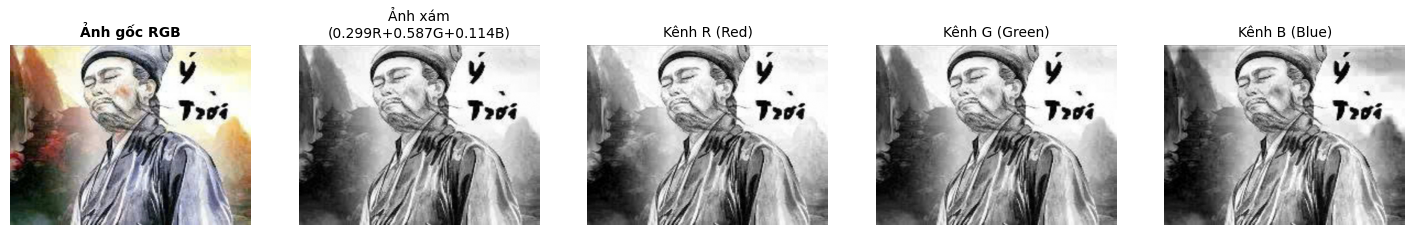

In [37]:
# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================
fig = plt.figure(figsize=(18, 12))

# Hàng 1: Ảnh gốc và ảnh xám
plt.subplot(4, 5, 1)
plt.imshow(img_rgb)
plt.title('Ảnh gốc RGB', fontsize=10, fontweight='bold')
plt.axis('off')

plt.subplot(4, 5, 2)
plt.imshow(img_gray_manual, cmap='gray')
plt.title('Ảnh xám\n(0.299R+0.587G+0.114B)', fontsize=10)
plt.axis('off')

# Hàng 1: Các kênh riêng lẻ
plt.subplot(4, 5, 3)
plt.imshow(channel_R, cmap='gray')
plt.title('Kênh R (Red)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 4)
plt.imshow(channel_G, cmap='gray')
plt.title('Kênh G (Green)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 5)
plt.imshow(channel_B, cmap='gray')
plt.title('Kênh B (Blue)', fontsize=10)
plt.axis('off')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

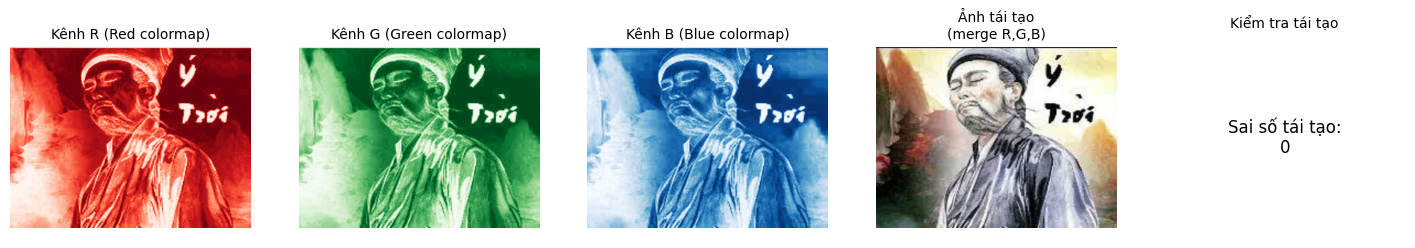

In [43]:
# Hàng 2: Kênh màu hiển thị với colormap tương ứng
fig = plt.figure(figsize=(18, 12))
plt.subplot(4, 5, 6)
plt.imshow(channel_R, cmap='Reds')
plt.title('Kênh R (Red colormap)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 7)
plt.imshow(channel_G, cmap='Greens')
plt.title('Kênh G (Green colormap)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 8)
plt.imshow(channel_B, cmap='Blues')
plt.title('Kênh B (Blue colormap)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 9)
plt.imshow(img_reconstructed)
plt.title('Ảnh tái tạo\n(merge R,G,B)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 10)
diff = np.sum(np.abs(img_rgb.astype(int) - img_reconstructed.astype(int)))
plt.text(0.5, 0.5, f'Sai số tái tạo:\n{diff}', 
         ha='center', va='center', fontsize=12, transform=plt.gca().transAxes)
plt.title('Kiểm tra tái tạo', fontsize=10)
plt.axis('off')

(np.float64(-0.5), np.float64(399.5), np.float64(299.5), np.float64(-0.5))

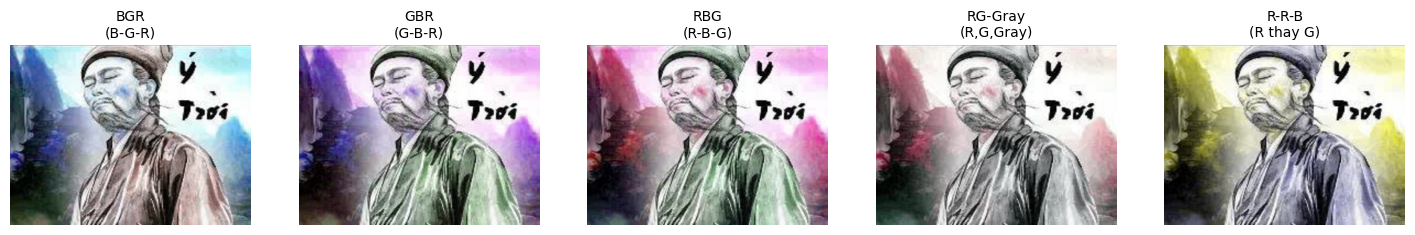

In [44]:
# Hàng 3: Hoán đổi kênh
fig = plt.figure(figsize=(18, 12))

plt.subplot(4, 5, 11)
plt.imshow(img_BGR)
plt.title('BGR\n(B-G-R)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 12)
plt.imshow(img_GBR)
plt.title('GBR\n(G-B-R)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 13)
plt.imshow(img_RBG)
plt.title('RBG\n(R-B-G)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 14)
plt.imshow(img_RG_gray)
plt.title('RG-Gray\n(R,G,Gray)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 15)
plt.imshow(img_R_R_B)
plt.title('R-R-B\n(R thay G)', fontsize=10)
plt.axis('off')

(np.float64(-0.5), np.float64(399.5), np.float64(299.5), np.float64(-0.5))

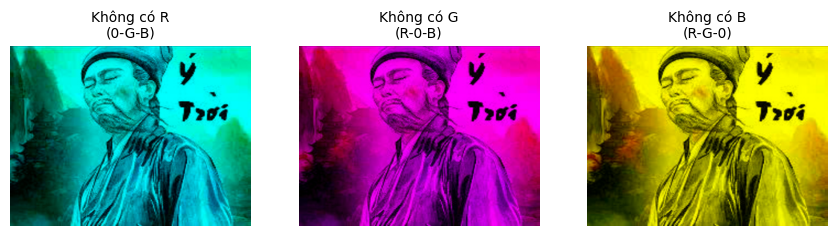

In [45]:
# Hàng 4: Loại bỏ kênh
fig = plt.figure(figsize=(18, 12))

plt.subplot(4, 5, 16)
plt.imshow(img_no_R)
plt.title('Không có R\n(0-G-B)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 17)
plt.imshow(img_no_G)
plt.title('Không có G\n(R-0-B)', fontsize=10)
plt.axis('off')

plt.subplot(4, 5, 18)
plt.imshow(img_no_B)
plt.title('Không có B\n(R-G-0)', fontsize=10)
plt.axis('off')

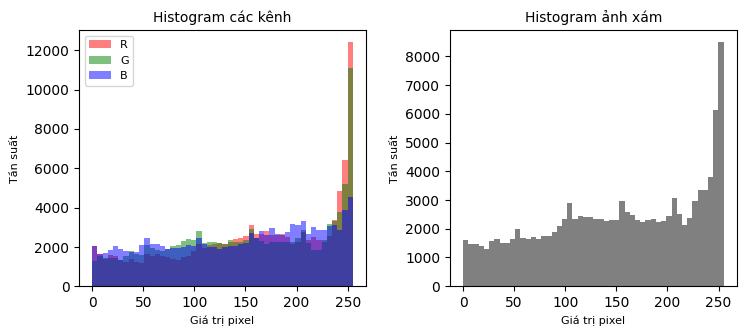

In [47]:
# Histogram so sánh
fig = plt.figure(figsize=(18, 12))

plt.subplot(4, 5, 19)
plt.hist(channel_R.ravel(), bins=50, alpha=0.5, color='red', label='R')
plt.hist(channel_G.ravel(), bins=50, alpha=0.5, color='green', label='G')
plt.hist(channel_B.ravel(), bins=50, alpha=0.5, color='blue', label='B')
plt.title('Histogram các kênh', fontsize=10)
plt.legend(fontsize=8)
plt.xlabel('Giá trị pixel', fontsize=8)
plt.ylabel('Tần suất', fontsize=8)

plt.subplot(4, 5, 20)
plt.hist(img_gray_manual.ravel(), bins=50, color='gray')
plt.title('Histogram ảnh xám', fontsize=10)
plt.xlabel('Giá trị pixel', fontsize=8)
plt.ylabel('Tần suất', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# THỐNG KÊ PHÂN TÍCH
# ============================================================
print("\n" + "="*60)
print("THỐNG KÊ PHÂN TÍCH")
print("="*60)

print(f"\n1. Thông tin ảnh gốc:")
print(f"   - Kích thước: {img_rgb.shape[0]}x{img_rgb.shape[1]} pixels")
print(f"   - Số kênh: {img_rgb.shape[2]}")
print(f"   - Tổng số pixel: {img_rgb.shape[0] * img_rgb.shape[1]:,}")

print(f"\n2. Thống kê từng kênh màu:")
print(f"   Kênh Red   - Min: {np.min(channel_R):3d}, Max: {np.max(channel_R):3d}, Mean: {np.mean(channel_R):6.2f}, Std: {np.std(channel_R):6.2f}")
print(f"   Kênh Green - Min: {np.min(channel_G):3d}, Max: {np.max(channel_G):3d}, Mean: {np.mean(channel_G):6.2f}, Std: {np.std(channel_G):6.2f}")
print(f"   Kênh Blue  - Min: {np.min(channel_B):3d}, Max: {np.max(channel_B):3d}, Mean: {np.mean(channel_B):6.2f}, Std: {np.std(channel_B):6.2f}")

print(f"\n3. Ảnh xám:")
print(f"   - Min: {np.min(img_gray_manual):3d}, Max: {np.max(img_gray_manual):3d}")
print(f"   - Mean: {np.mean(img_gray_manual):6.2f}, Std: {np.std(img_gray_manual):6.2f}")

print(f"\n4. Kiểm tra tính toàn vẹn:")
print(f"   - Sai số tái tạo RGB: {np.sum(np.abs(img_rgb.astype(int) - img_reconstructed.astype(int)))}")
print(f"   - Tái tạo hoàn hảo: {'Có' if np.array_equal(img_rgb, img_reconstructed) else 'Không'}")

print("\n" + "="*60)
print("Code đã thực thi thành công!")
print("="*60)


THỐNG KÊ PHÂN TÍCH

1. Thông tin ảnh gốc:
   - Kích thước: 300x400 pixels
   - Số kênh: 3
   - Tổng số pixel: 120,000

2. Thống kê từng kênh màu:
   Kênh Red   - Min:   0, Max: 255, Mean: 157.57, Std:  75.65
   Kênh Green - Min:   0, Max: 255, Mean: 150.39, Std:  75.36
   Kênh Blue  - Min:   0, Max: 255, Mean: 142.45, Std:  74.49

3. Ảnh xám:
   - Min:   0, Max: 255
   - Mean: 151.14, Std:  74.54

4. Kiểm tra tính toàn vẹn:
   - Sai số tái tạo RGB: 0
   - Tái tạo hoàn hảo: Có

Code đã thực thi thành công!
Hình ảnh đã được lưu: output/color_image_representation.png
